# Inspect MaskablePPO Training Results

This notebook loads the trained MaskablePPO model and verifies:
1. Action distribution is balanced (not 99% one action)
2. No invalid actions are taken (BUY while LONG, SELL while SHORT)
3. Policy performance on train/eval data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sb3_contrib import MaskablePPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

from rl_trading_lab.environment.trading_env import TradingEnv, Action
from rl_trading_lab.environment.factory import create_make_env
from hydra import compose, initialize

import warnings
warnings.filterwarnings('ignore')

## 1. Load Configuration and Data

In [4]:
# Load config
with initialize(config_path="../configs", version_base=None):
    config = compose(config_name="config", overrides=["agent=maskable_ppo"])

# Hardcoded data path (config doesn't have data.path field)
data_path = "../../tools/examples/btcusdt_fractional_indicators.parquet"

# Create environment factory
make_env = create_make_env(
    data_path=data_path,
    observation_config=config.observation,
    feature_engineering_config=config.feature_engineering,
    env_config=config.env,
    val_split=config.data.val_split,
    test_split=config.data.test_split,
)

print("✓ Configuration loaded")

✓ Configuration loaded


## 2. Find Latest MaskablePPO Checkpoint

In [5]:
# Find latest MaskablePPO checkpoint
checkpoint_dir = Path("../checkpoints")
maskable_ppo_runs = sorted(checkpoint_dir.glob("MaskablePPO_*"), key=lambda x: x.stat().st_mtime, reverse=True)

if not maskable_ppo_runs:
    print("❌ No MaskablePPO checkpoints found!")
    print("Wait for training to complete or check the checkpoint directory.")
else:
    latest_run = maskable_ppo_runs[0]
    model_path = latest_run / "best_model" / "best_model.zip"
    vecnorm_path = latest_run / "best_model" / "vecnormalize.pkl"
    
    print(f"Latest run: {latest_run.name}")
    print(f"Model path: {model_path}")
    print(f"Model exists: {model_path.exists()}")
    print(f"VecNormalize exists: {vecnorm_path.exists()}")

Latest run: MaskablePPO_returns_20251031_042930
Model path: ../checkpoints/MaskablePPO_returns_20251031_042930/best_model/best_model.zip
Model exists: True
VecNormalize exists: True


## 3. Load Model and Environment

In [6]:
if not model_path.exists():
    print("⏳ Model not found. Training may still be in progress.")
    print("Wait for training to save the first checkpoint.")
else:
    # Load model
    print("Loading MaskablePPO model...")
    model = MaskablePPO.load(model_path)
    print("✓ Model loaded")
    
    # Create environment
    train_env_raw = make_env('train')
    train_env = DummyVecEnv([lambda: train_env_raw])
    
    # Load VecNormalize stats if they exist
    if vecnorm_path.exists():
        train_env = VecNormalize.load(vecnorm_path, train_env)
        train_env.training = False  # Don't update stats
        train_env.norm_reward = False  # Don't normalize rewards for evaluation
        print("✓ VecNormalize stats loaded")
    
    print("✓ Environment created")

Loading MaskablePPO model...
✓ Model loaded
✓ VecNormalize stats loaded
✓ Environment created


## 4. Run Episode and Collect Data

In [7]:
if model_path.exists():
    print("Running episode to collect data...")
    
    obs = train_env.reset()
    done = False
    step = 0
    max_steps = 500
    
    # Data collection
    actions_taken = []
    positions = []
    rewards = []
    portfolio_values = []
    invalid_actions = []
    
    while not done and step < max_steps:
        # Get action masks from environment
        unwrapped_env = train_env.envs[0]
        if hasattr(unwrapped_env, 'venv'):
            trading_env = unwrapped_env.venv.envs[0]
        else:
            trading_env = unwrapped_env
        
        action_mask = trading_env.action_masks()
        position_before = trading_env.portfolio.position.size
        
        # Predict action (MaskablePPO will respect the mask)
        action, _ = model.predict(obs, action_masks=action_mask, deterministic=False)
        
        # Check if action was valid
        is_valid = action_mask[action[0]]
        if not is_valid:
            invalid_actions.append({
                'step': step,
                'position': position_before,
                'action': Action(action[0]).name,
                'mask': action_mask.tolist()
            })
        
        # Take step
        obs, reward, done, info = train_env.step(action)
        
        # Collect data
        actions_taken.append(action[0])
        positions.append(info[0]['position'])
        rewards.append(reward[0])
        portfolio_values.append(info[0]['portfolio_value'])
        
        step += 1
        
        if done[0]:
            print(f"Episode ended at step {step}")
            break
    
    print(f"\n✓ Collected {step} steps of data")
    print(f"\nInvalid actions: {len(invalid_actions)}")
    if invalid_actions:
        print("\n❌ WARNING: Invalid actions were sampled!")
        for inv in invalid_actions[:5]:
            print(f"  Step {inv['step']}: {inv['action']} with position={inv['position']:.2f}, mask={inv['mask']}")
    else:
        print("✓ No invalid actions sampled!")

Running episode to collect data...

✓ Collected 500 steps of data

Invalid actions: 0
✓ No invalid actions sampled!


## 5. Action Distribution Analysis

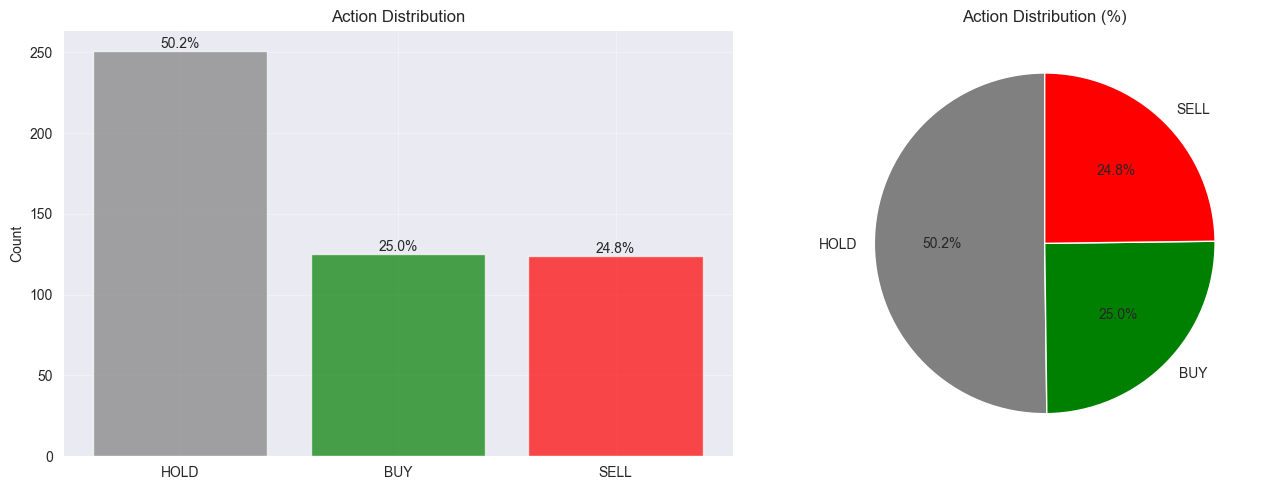


Action Distribution:
  HOLD :  251 ( 50.2%)
  BUY  :  125 ( 25.0%)
  SELL :  124 ( 24.8%)

✓ Policy appears balanced (max 50.2%)


In [8]:
if model_path.exists():
    action_counts = pd.Series(actions_taken).value_counts().sort_index()
    action_names = [Action.HOLD.name, Action.BUY.name, Action.SELL.name]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    colors = ['gray', 'green', 'red']
    bars = ax1.bar(range(len(action_counts)), action_counts.values, color=colors, alpha=0.7)
    ax1.set_xticks(range(len(action_counts)))
    ax1.set_xticklabels([action_names[i] for i in action_counts.index])
    ax1.set_ylabel('Count')
    ax1.set_title('Action Distribution')
    ax1.grid(True, alpha=0.3)
    
    # Add percentages on bars
    for i, (bar, count) in enumerate(zip(bars, action_counts.values)):
        pct = 100 * count / len(actions_taken)
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{pct:.1f}%', ha='center', va='bottom')
    
    # Pie chart
    ax2.pie(action_counts.values, labels=[action_names[i] for i in action_counts.index], 
            autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Action Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAction Distribution:")
    for idx, count in action_counts.items():
        pct = 100 * count / len(actions_taken)
        print(f"  {action_names[idx]:5s}: {count:4d} ({pct:5.1f}%)")
    
    # Check for degenerate policy
    max_pct = 100 * action_counts.max() / len(actions_taken)
    if max_pct > 90:
        print(f"\n⚠️  WARNING: Degenerate policy detected! {max_pct:.1f}% of actions are the same.")
    else:
        print(f"\n✓ Policy appears balanced (max {max_pct:.1f}%)")

## 6. Position and Portfolio Analysis

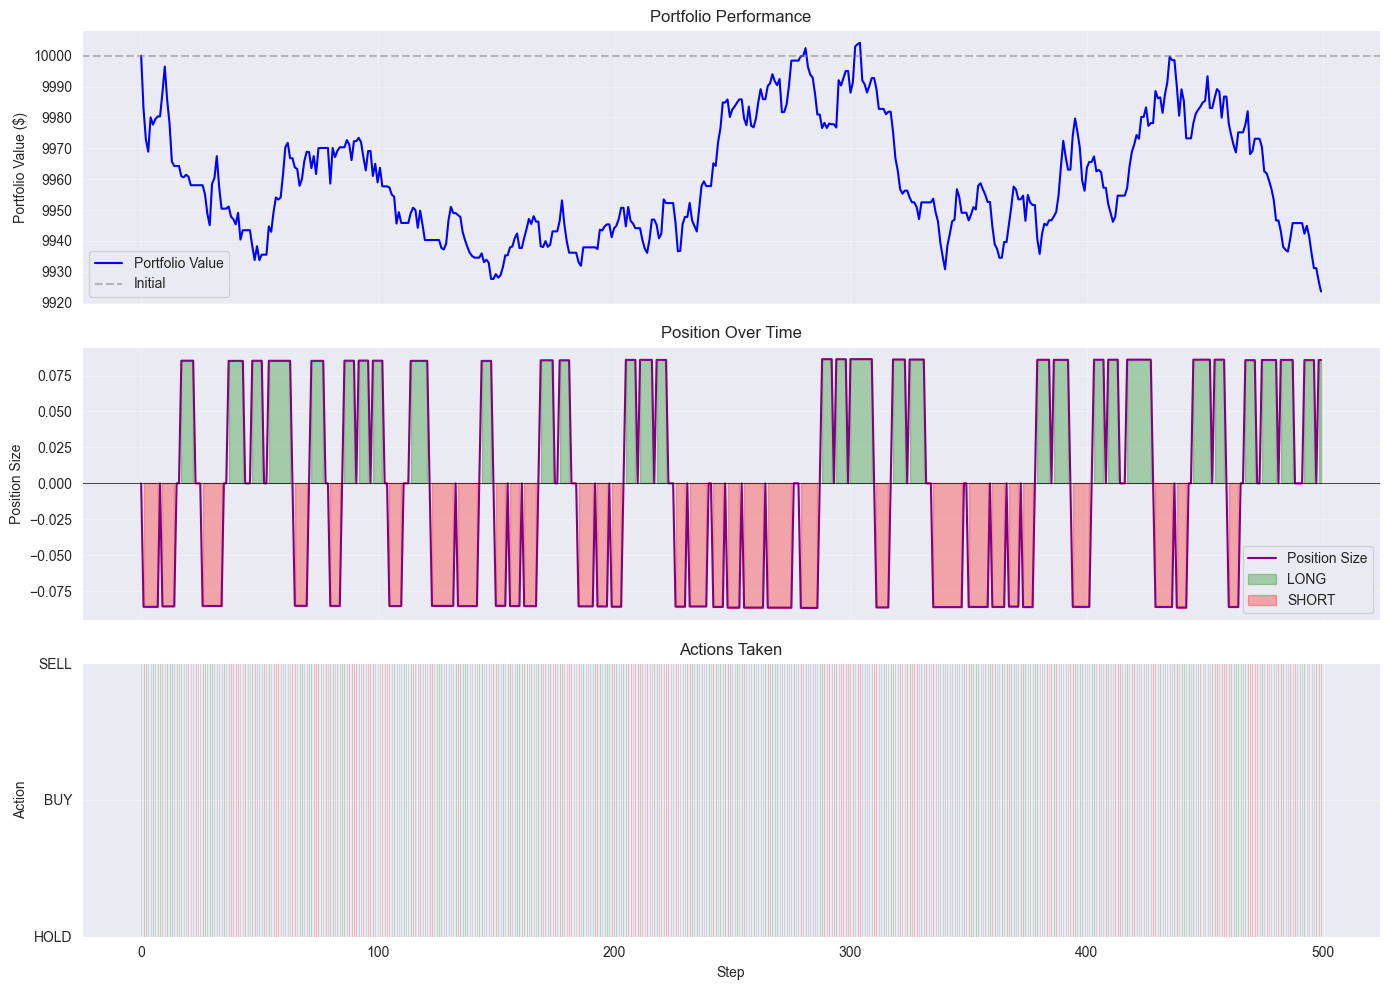


Episode Summary:
  Steps: 500
  Initial balance: $10,000
  Final portfolio value: $9,923.60
  Total return: -0.76%


In [9]:
if model_path.exists():
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Portfolio value
    axes[0].plot(portfolio_values, label='Portfolio Value', color='blue')
    axes[0].axhline(y=10000, color='gray', linestyle='--', alpha=0.5, label='Initial')
    axes[0].set_ylabel('Portfolio Value ($)')
    axes[0].set_title('Portfolio Performance')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Position size
    axes[1].plot(positions, label='Position Size', color='purple')
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].fill_between(range(len(positions)), 0, positions, 
                         where=np.array(positions) > 0, alpha=0.3, color='green', label='LONG')
    axes[1].fill_between(range(len(positions)), 0, positions, 
                         where=np.array(positions) < 0, alpha=0.3, color='red', label='SHORT')
    axes[1].set_ylabel('Position Size')
    axes[1].set_title('Position Over Time')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Actions
    action_colors = ['gray', 'green', 'red']
    for i, action in enumerate(actions_taken):
        axes[2].axvline(x=i, color=action_colors[action], alpha=0.3, linewidth=0.5)
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Action')
    axes[2].set_title('Actions Taken')
    axes[2].set_yticks([0, 1, 2])
    axes[2].set_yticklabels(['HOLD', 'BUY', 'SELL'])
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    final_value = portfolio_values[-1]
    total_return = (final_value - 10000) / 10000 * 100
    
    print(f"\nEpisode Summary:")
    print(f"  Steps: {len(actions_taken)}")
    print(f"  Initial balance: $10,000")
    print(f"  Final portfolio value: ${final_value:,.2f}")
    print(f"  Total return: {total_return:+.2f}%")

## 7. Training Metrics (if available)

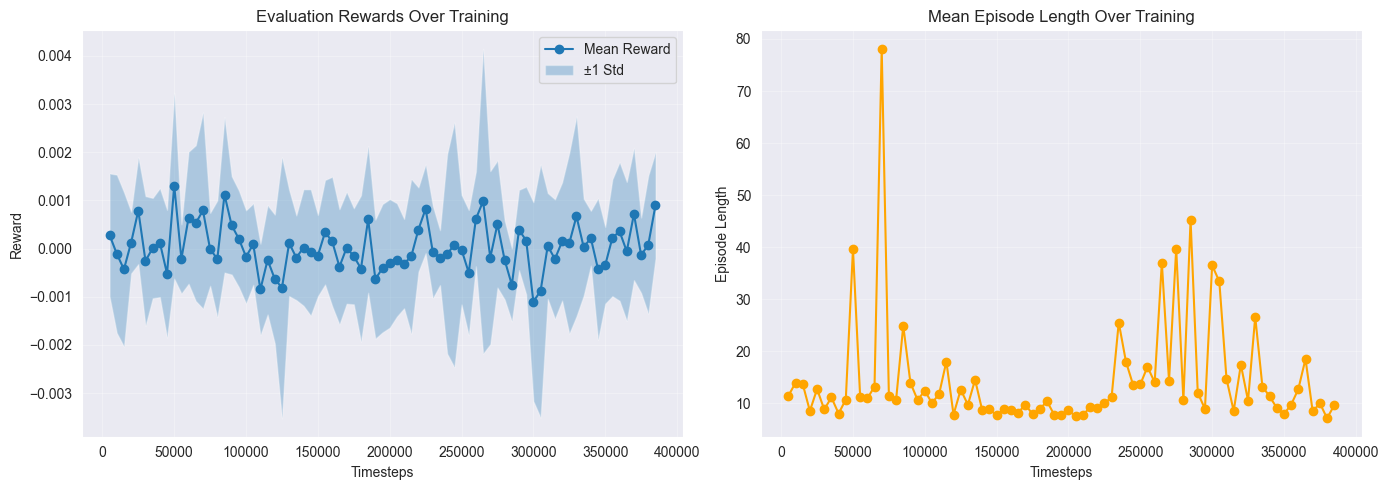


Training Progress:
  Total timesteps: 385,000
  Latest mean reward: 0.0009
  Latest mean ep length: 9.6


In [10]:
if model_path.exists():
    eval_logs_path = latest_run / "eval_logs" / "evaluations.npz"
    
    if eval_logs_path.exists():
        eval_data = np.load(eval_logs_path)
        timesteps = eval_data['timesteps']
        results = eval_data['results']
        ep_lengths = eval_data['ep_lengths']
        
        mean_rewards = results.mean(axis=1)
        std_rewards = results.std(axis=1)
        mean_lengths = ep_lengths.mean(axis=1)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Evaluation rewards
        ax1.plot(timesteps, mean_rewards, marker='o', label='Mean Reward')
        ax1.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, 
                         alpha=0.3, label='±1 Std')
        ax1.set_xlabel('Timesteps')
        ax1.set_ylabel('Reward')
        ax1.set_title('Evaluation Rewards Over Training')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Episode lengths
        ax2.plot(timesteps, mean_lengths, marker='o', color='orange')
        ax2.set_xlabel('Timesteps')
        ax2.set_ylabel('Episode Length')
        ax2.set_title('Mean Episode Length Over Training')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nTraining Progress:")
        print(f"  Total timesteps: {timesteps[-1]:,}")
        print(f"  Latest mean reward: {mean_rewards[-1]:.4f}")
        print(f"  Latest mean ep length: {mean_lengths[-1]:.1f}")
    else:
        print("⏳ Evaluation logs not found yet. Training may still be in progress.")

## Summary

This notebook shows:
1. **Action Distribution**: Should be more balanced than the 99% SELL we saw with A2C
2. **Invalid Actions**: Should be 0 (MaskablePPO prevents them)
3. **Trading Behavior**: Agent should take both LONG and SHORT positions appropriately
4. **Training Progress**: Rewards and episode lengths over time